#### Load Dependencies 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import yaml
import numpy as np
import os

In [3]:
### Check the current working directory
print(os.getcwd())

d:\Joseph\Projects\kg-default-of-credit-cards\notebooks


#### Load Data


**ID**: ID of each client  
**LIMIT_BAL**: Amount of given credit in NT dollars (includes individual and family/supplementary credit  
**SEX**: Gender (1=male, 2=female)  
**EDUCATION**: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)  
**MARRIAGE**: Marital status (1=married, 2=single, 3=others)  
**AGE**: Age in years  
**PAY_0**: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)  
**PAY_2**: Repayment status in August, 2005 (scale same as above)  
**PAY_3**: Repayment status in July, 2005 (scale same as above)  
**PAY_4**: Repayment status in June, 2005 (scale same as above)  
**PAY_5**: Repayment status in May, 2005 (scale same as above)  
**PAY_6**: Repayment status in April, 2005 (scale same as above)  
**BILL_AMT1**: Amount of bill statement in September, 2005 (NT dollar)  
**BILL_AMT2**: Amount of bill statement in August, 2005 (NT dollar)  
**BILL_AMT3**: Amount of bill statement in July, 2005 (NT dollar)  
**BILL_AMT4**: Amount of bill statement in June, 2005 (NT dollar)  
**BILL_AMT5**: Amount of bill statement in May, 2005 (NT dollar)  
**BILL_AMT6**: Amount of bill statement in April, 2005 (NT dollar)  
**PAY_AMT1**: Amount of previous payment in September, 2005 (NT dollar)  
**PAY_AMT2**: Amount of previous payment in August, 2005 (NT dollar)  
**PAY_AMT3**: Amount of previous payment in July, 2005 (NT dollar)  
**PAY_AMT4**: Amount of previous payment in June, 2005 (NT dollar)  
**PAY_AMT5**: Amount of previous payment in May, 2005 (NT dollar)  
**PAY_AMT6**: Amount of previous payment in April, 2005 (NT dollar)  
***default.payment.next.month***: Default payment (1=yes, 0=no)  


In [4]:
# read csv file
df = pd.read_csv("../data/UCI_Credit_Card.csv")

### Explore Data

In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
# Determine the data types of each column in the training data 
print(df.info())

# Define the target variable
target_variable = 'default.payment.next.month'


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [7]:
# Determine the basistic statistics of each column in the training data except for the ID column
print(df.describe().drop(['ID'], axis=1))




            LIMIT_BAL           SEX     EDUCATION      MARRIAGE           AGE  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.853133      1.551867     35.485500   
std     129747.661567      0.489129      0.790349      0.521970      9.217904   
min      10000.000000      1.000000      0.000000      0.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      6.000000      3.000000     79.000000   

              PAY_0         PAY_2         PAY_3         PAY_4         PAY_5  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        1.123802      1.197186

In [8]:
# RENAME PAY_0 to PAY_1 for consistency with the other PAY variables
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)


In [9]:
# Determine if there are any missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


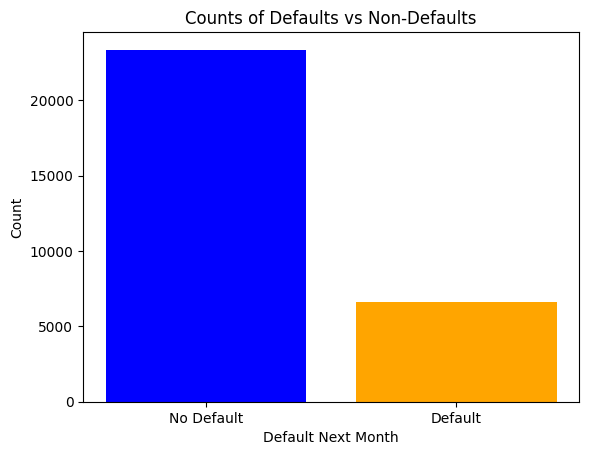

In [10]:
# Plot the distribution of the target variable 'default.payment.next.month'
plt.bar(
    df['default.payment.next.month'].value_counts().index, 
    df['default.payment.next.month'].value_counts().values, 
    color=['blue', 'orange']
)
plt.xticks([0,1], ['No Default','Default'])
plt.xlabel('Default Next Month')
plt.ylabel('Count')
plt.title('Counts of Defaults vs Non-Defaults')
plt.show()

In [11]:
# Ratio of defaults to non-defaults
default_counts = df['default.payment.next.month'].value_counts()
default_ratio = default_counts[1] / default_counts[0]
print(f"Ratio of defaults to non-defaults: {default_ratio:.4f}")

# Ratio of defaults to total samples
default_ratio_total = default_counts[1] / len(df)
print(f"Ratio of defaults to total samples: {default_ratio_total:.4f}")

Ratio of defaults to non-defaults: 0.2840
Ratio of defaults to total samples: 0.2212


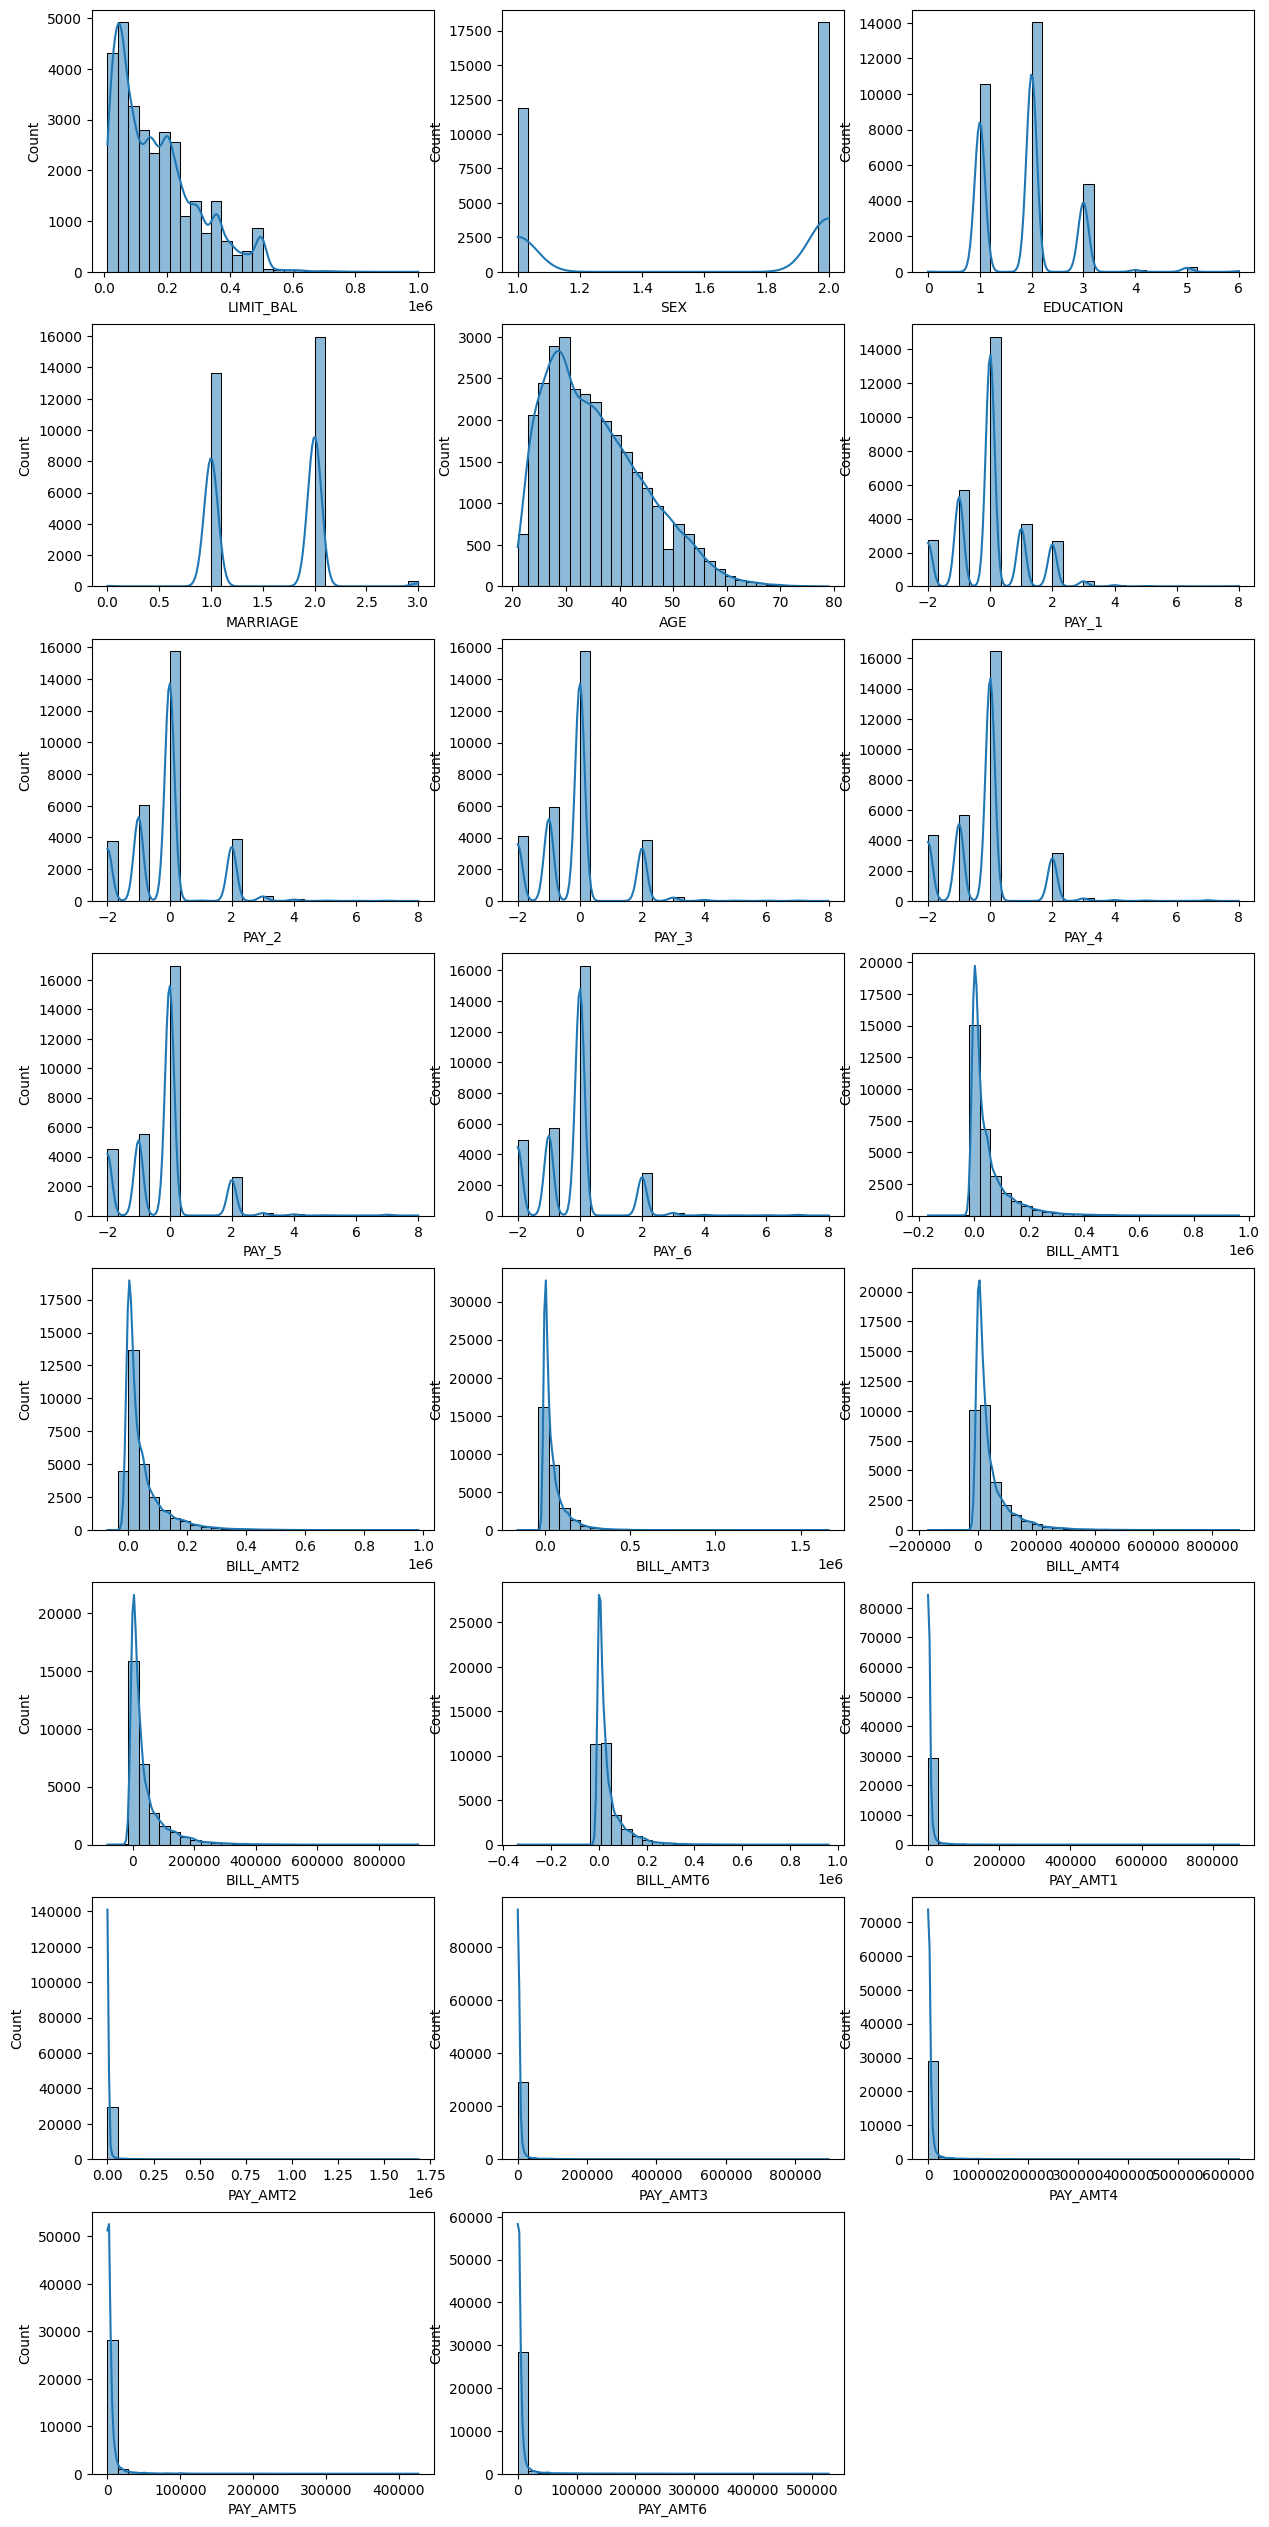

In [12]:
# Plot the distribution of the explanatory variables in 3 columns
explanatory_variables = [col for col in df.columns if (col != target_variable and col != 'ID')]
num_explanatory = len(explanatory_variables)
num_cols = 3    
num_rows = (num_explanatory + num_cols - 1) // num_cols  # Calculate required rows
plt.figure(figsize=(15, num_rows * 4))  # Adjust height based on number of rows
for i, var in enumerate(explanatory_variables):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[var], kde=True, bins=30)


In [13]:
binary_variables = ["SEX", "MARRIAGE"]
ordinal_variables = ["EDUCATION", "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
numeric_variables = [col for col in df.columns if (col not in binary_variables and col not in ordinal_variables and col != target_variable and col != 'ID')]
print("numeric_variables:", numeric_variables)

numeric_variables: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


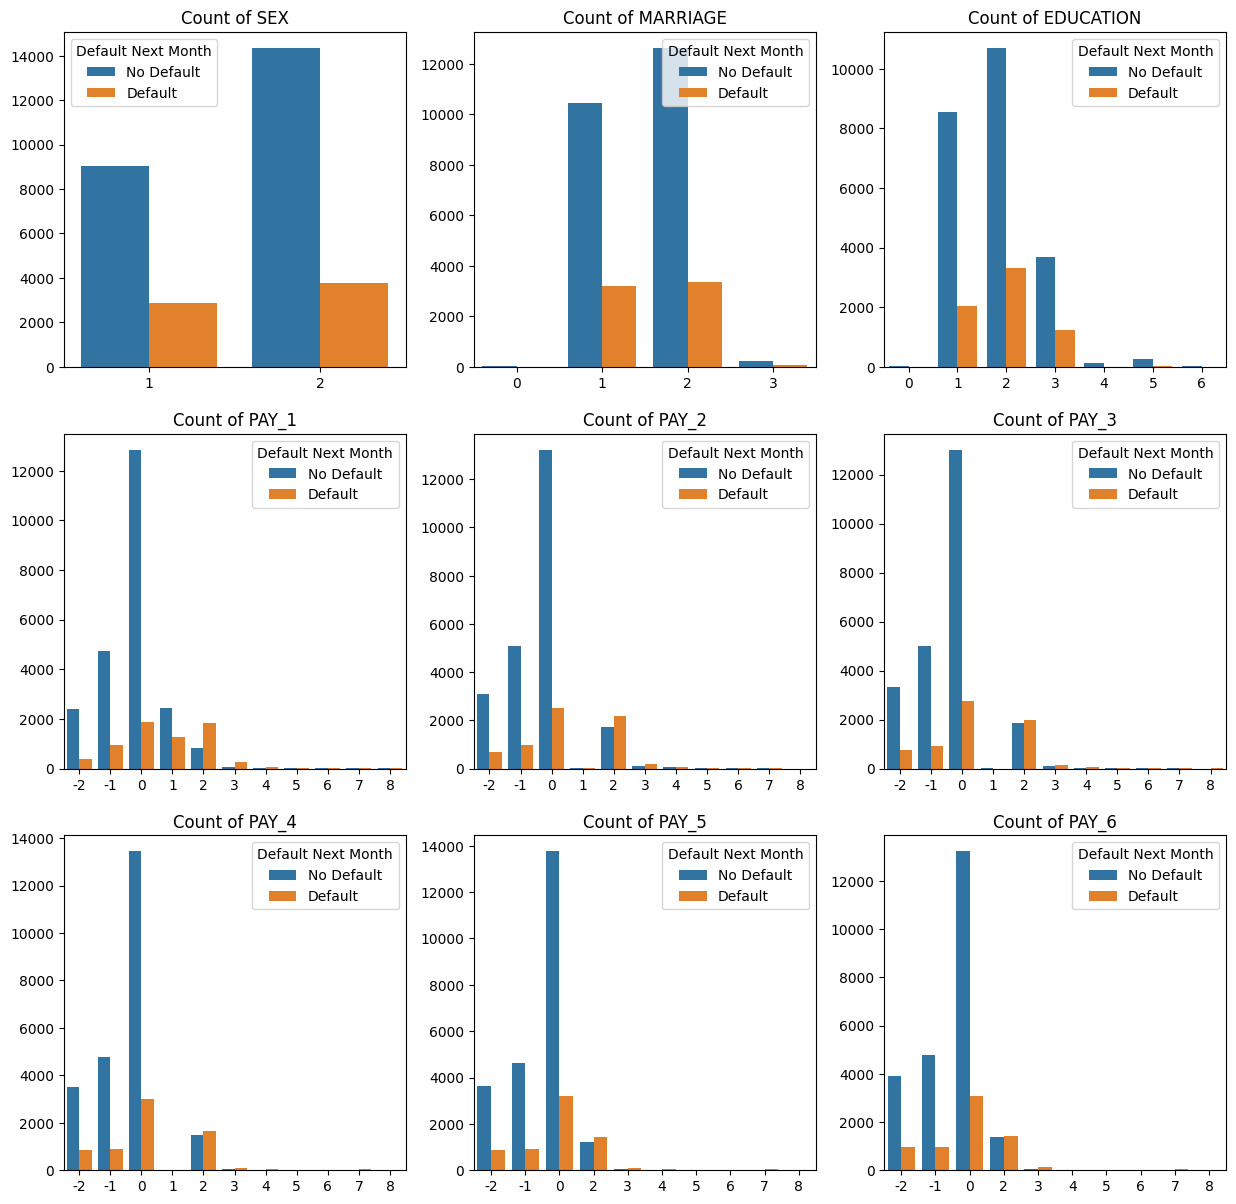

In [14]:
# Bar plot for binary variables and ordinal variables vs the target variable in 3 columns  
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(binary_variables + ordinal_variables):
    plt.subplot(4, 3, i + 1)
    sns.countplot(x=var, hue=target_variable, data=df)
    plt.title(f'Count of {var}')
    plt.xlabel("")
    plt.ylabel("")
    plt.legend(title='Default Next Month', labels=['No Default', 'Default'])    

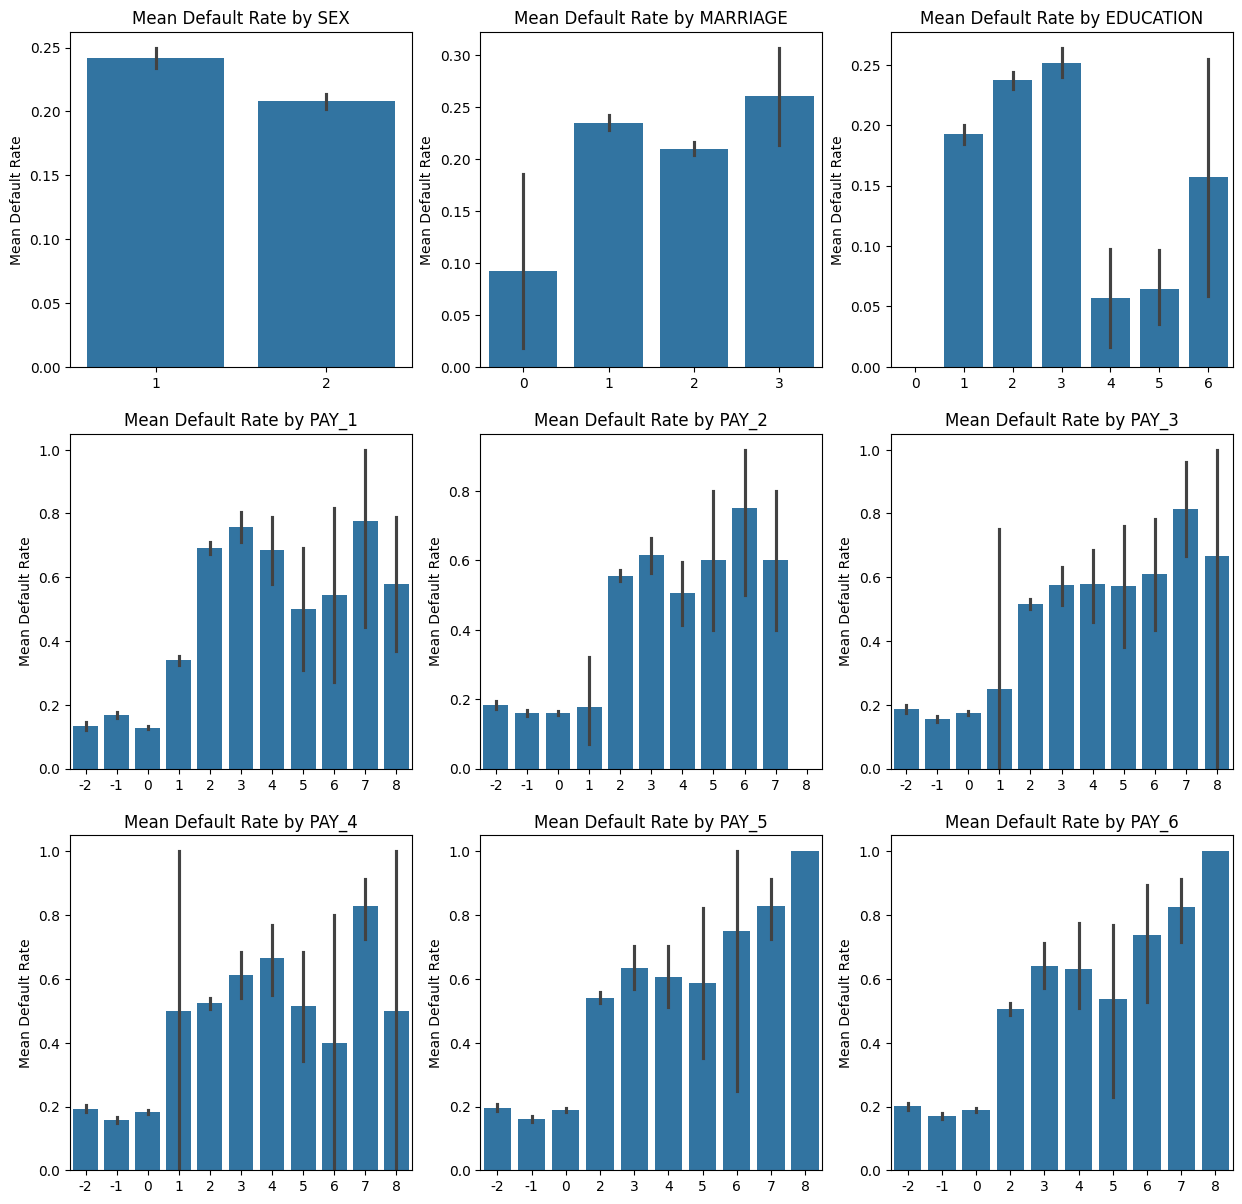

In [15]:
# For non-numeric variables, calculate the mean of the target variable for each category and plot a bar plot
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(binary_variables + ordinal_variables):
    plt.subplot(4, 3, i + 1)
    sns.barplot(x=var, y=target_variable, data=df)
    plt.title(f'Mean Default Rate by {var}')
    plt.xlabel("")
    plt.ylabel("Mean Default Rate")
    

*PAY_1 to PAY_6*  
* -2,-1,0: low default rate  
* else: high default rate

*SEX* -- seems unrelevant since default rates are not very different

*MARRIAGE* and *EDUCATION* -- default rates vary

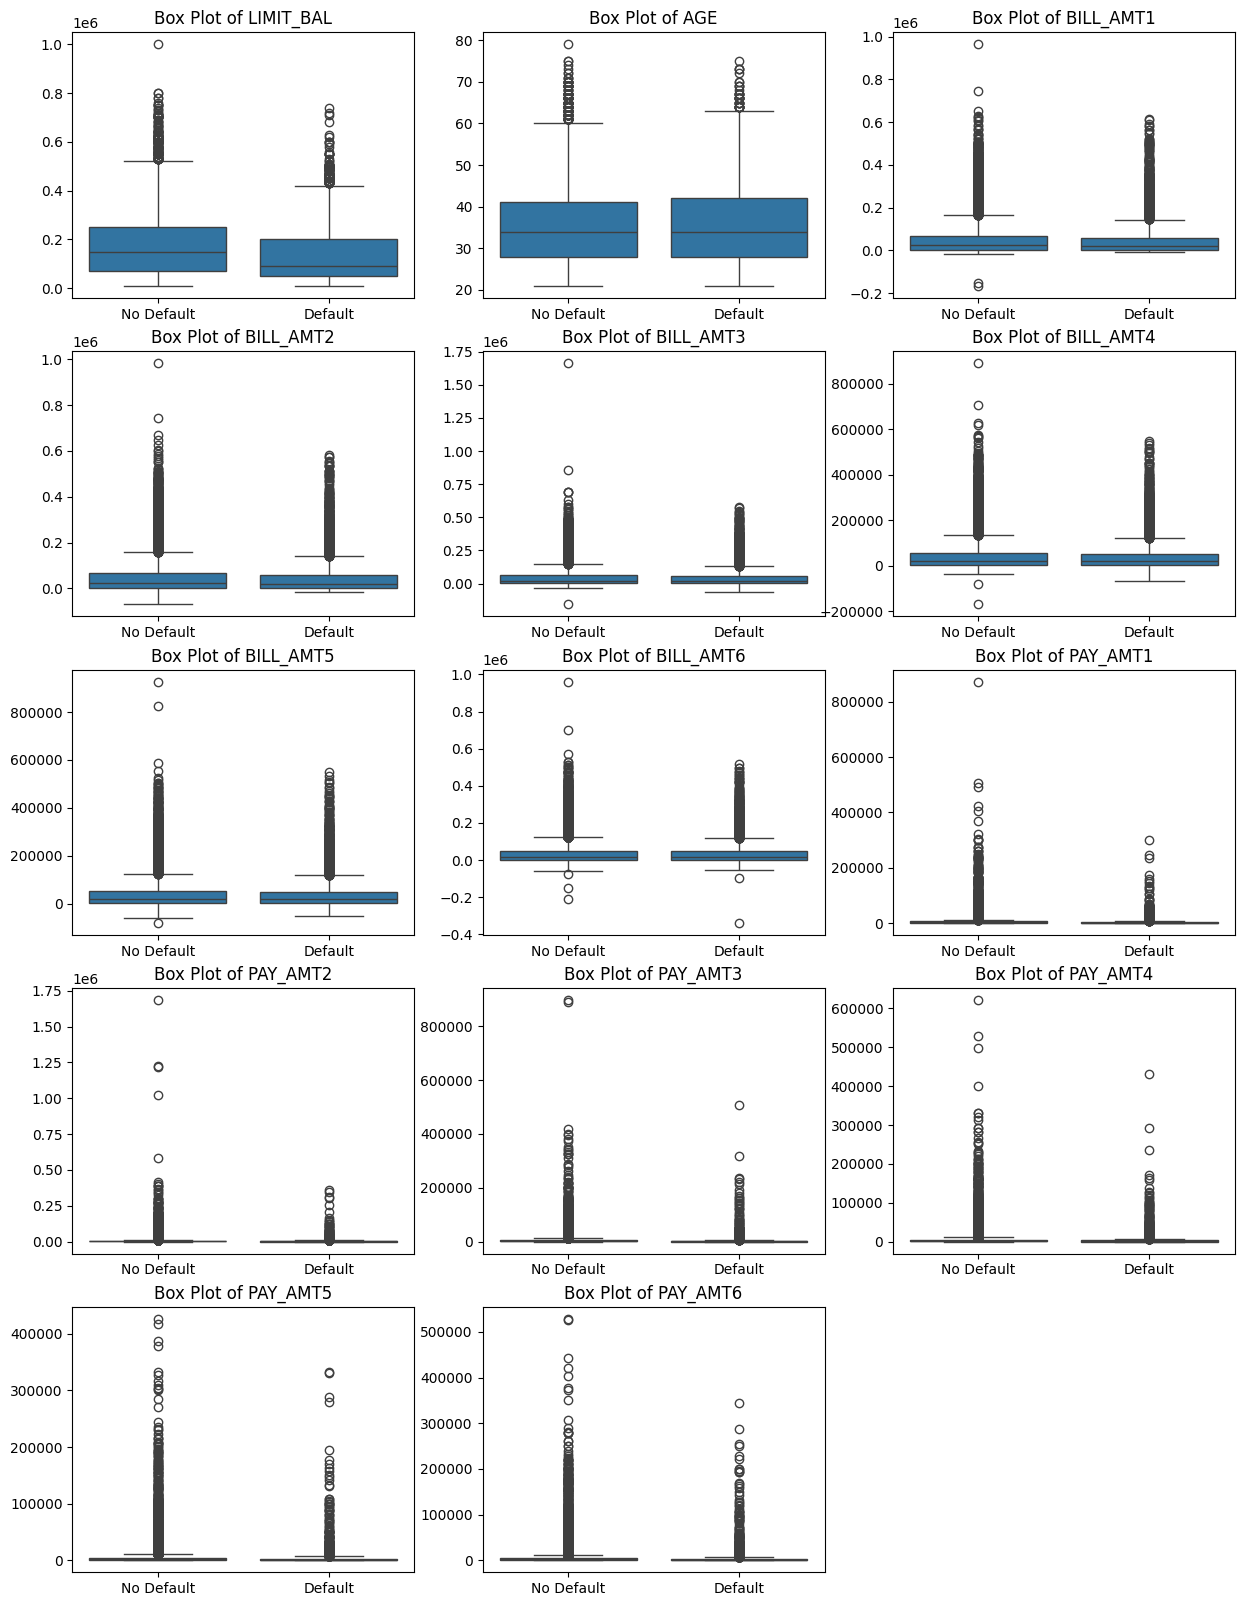

In [16]:
# Box plot for numeric variables vs the target variable in 3 columns
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(numeric_variables):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(x=target_variable, y=var, data=df)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'Box Plot of {var}')
    plt.xticks([0,1], ['No Default','Default'])

ValueError: Bin edges must be unique: Index([0.0, 0.0, 1000.0, 2100.0, 5000.0, 621000.0], dtype='float64', name='PAY_AMT4').
You can drop duplicate edges by setting the 'duplicates' kwarg

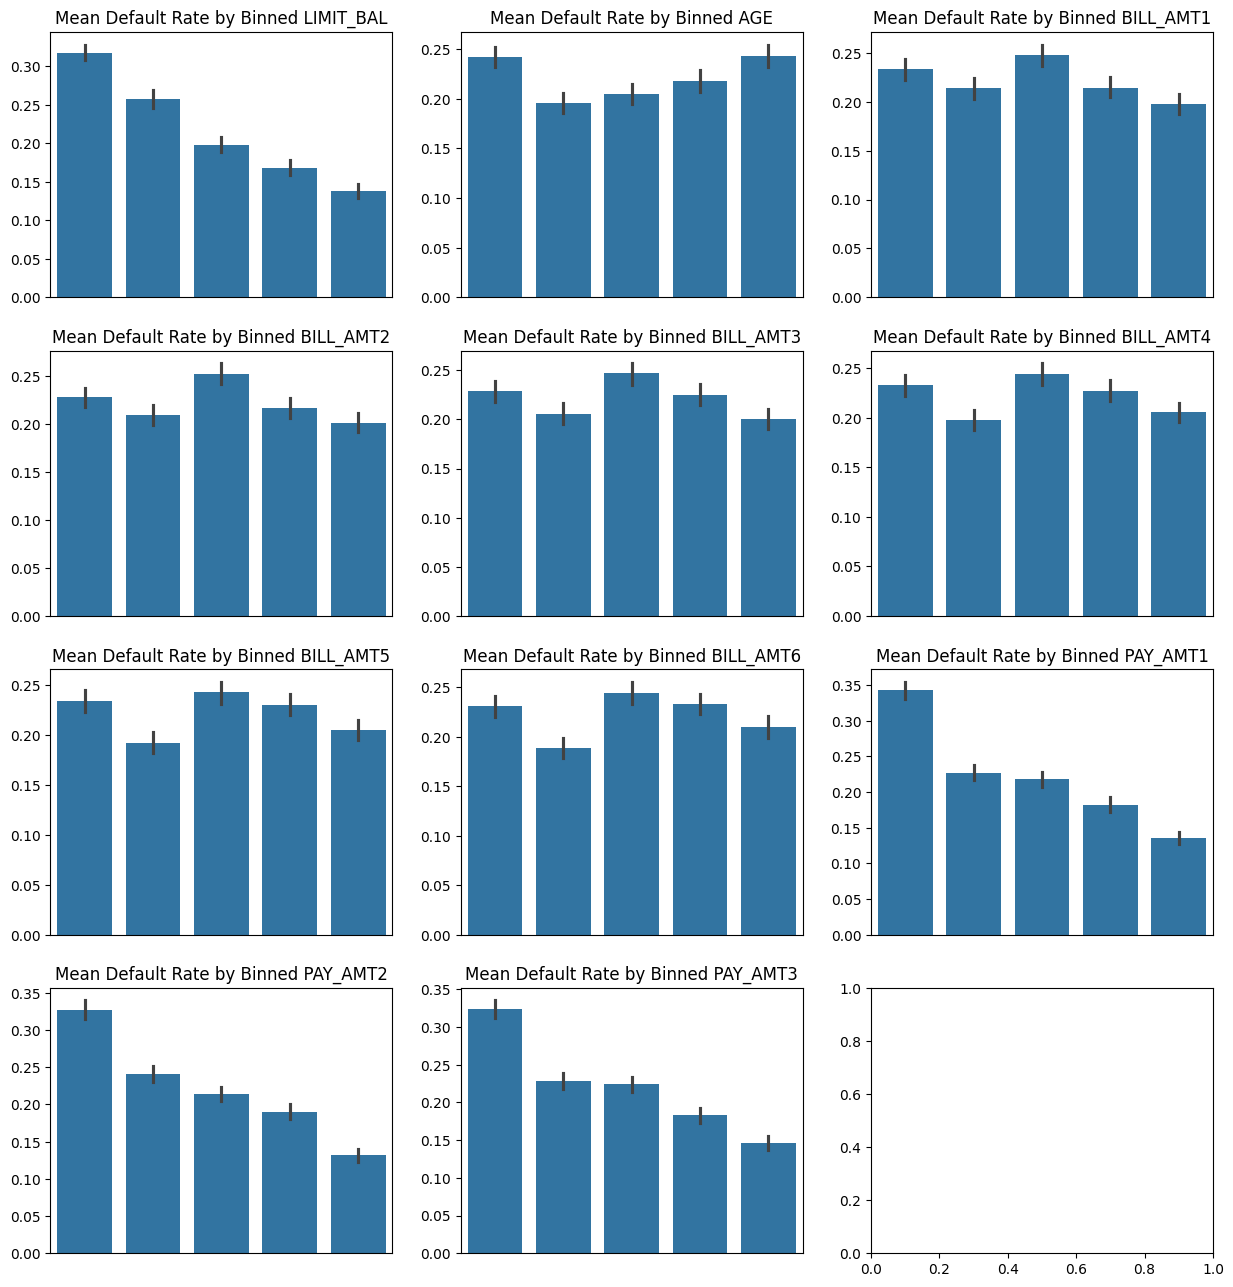

In [18]:
# Create barplots for each numeric variable against the target variable with at most 5 bins, using the maximum numeric variable on the x-axis
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(numeric_variables):
    plt.subplot(5, 3, i + 1)
    df[f'{var}_binned'] = pd.qcut(df[var], q=5)
    sns.barplot(x=f'{var}_binned', y=target_variable, data=df)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'Mean Default Rate by Binned {var}')
    plt.xticks([])

##### Relevant variables
* PAY_AMT<>
* LIMIT_BALANCE

#### Non-relevant variables
* BILL_AMT
* AGE

##### Potential feature engineering

* Average Payment

0     114.833333
1     833.333333
2    1836.333333
3    1398.000000
4    9841.500000
dtype: float64


Text(0.5, 1.0, 'Average Payment by Default Next Month')

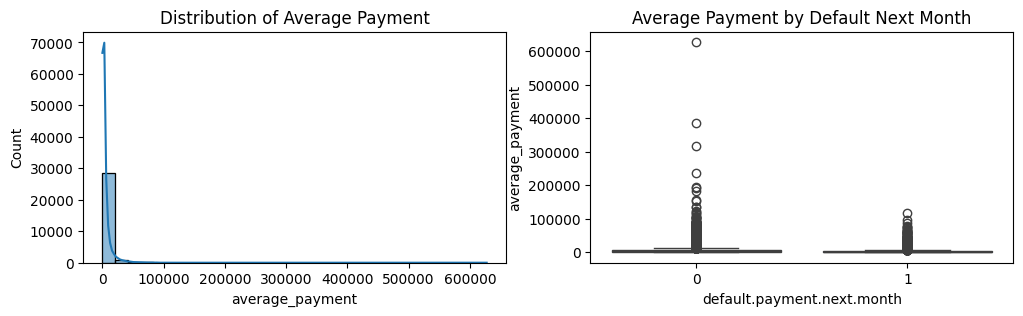

In [19]:
# Average payment per observation for the PAY_AMT1 to PAY_AMT6 variables
payment_vars = [f'PAY_AMT{i+1}' for i in range(6)]
payment_means = df[payment_vars].mean(axis=1)
df['average_payment'] = payment_means
print(payment_means.head())

# Plot the distribution of the average payment variable
plt.figure(figsize=(12,3))
plt.subplot(1, 2, 1)
sns.histplot(df['average_payment'], kde=True, bins=30)
plt.title('Distribution of Average Payment')
plt.subplot(1, 2, 2)
sns.boxplot(x=target_variable, y='average_payment', data=df)
plt.title('Average Payment by Default Next Month')

* Average Bill

0     1284.000000
1     2846.166667
2    16942.166667
3    38555.666667
4    18223.166667
dtype: float64


Text(0.5, 1.0, 'Average Bill by Default Next Month')

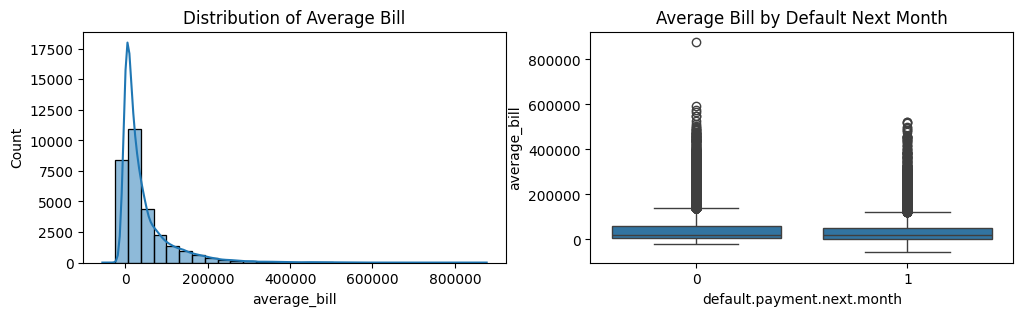

In [20]:
# Average bills per observation for the BILL_AMT1 to BILL_AMT6 variables
bill_vars = [f'BILL_AMT{i+1}' for i in range(6)]
bill_means = df[bill_vars].mean(axis=1) 
df['average_bill'] = bill_means
print(bill_means.head())

# Plot the distribution of the average bill variable
plt.figure(figsize=(12,3))
plt.subplot(1, 2, 1)    
sns.histplot(df['average_bill'], kde=True, bins=30)
plt.title('Distribution of Average Bill')
plt.subplot(1, 2, 2)
sns.boxplot(x=target_variable, y='average_bill', data=df)
plt.title('Average Bill by Default Next Month') 


* Average Balance : OK

   balance_1  balance_2  balance_3  balance_4  balance_5  balance_6
0     3913.0     2413.0      689.0        0.0        0.0        0.0
1     2682.0      725.0     1682.0     2272.0     3455.0     1261.0
2    27721.0    12527.0    12559.0    13331.0    13948.0    10549.0
3    44990.0    46214.0    48091.0    27214.0    27890.0    28547.0
4     6617.0   -31011.0    25835.0    11940.0    18457.0    18452.0

Average balance seems to be higher for those who do not default next month, which is counterintuitive (from the boxplots).
Let's check the distribution of the balance variables for those who default and those who do not default next month.


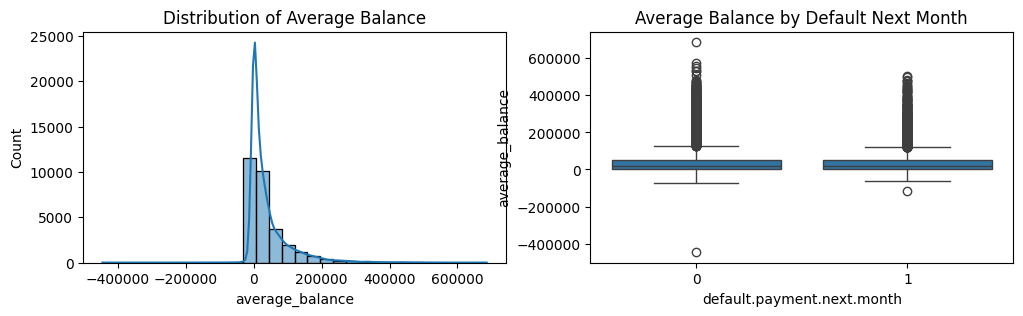

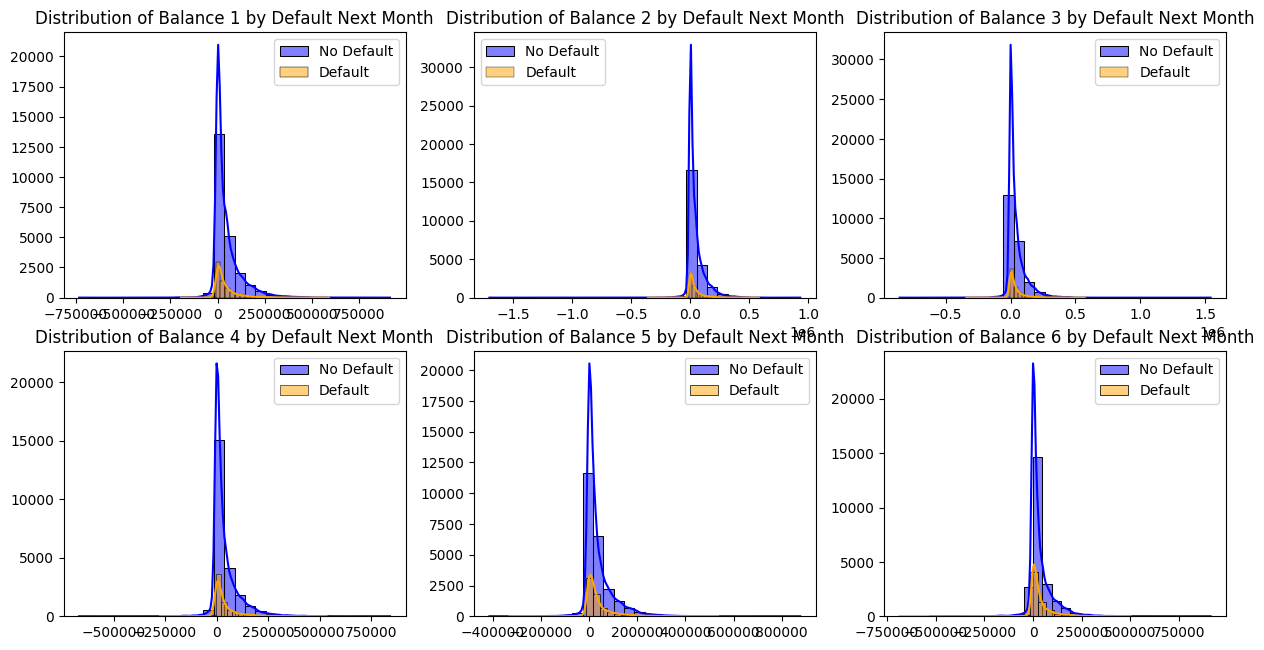

In [32]:
# Define the balance on Month i as difference the BILL_AMTi and PAY_AMTi variables for i=1 to 6
for i in range(1, 7):
    df[f'balance_{i}'] = df[f'BILL_AMT{i}'] - df[f'PAY_AMT{i}']
print(df[['balance_1', 'balance_2', 'balance_3', 'balance_4', 'balance_5', 'balance_6']].head())

# Average of the balance variables
balance_vars = [f'balance_{i}' for i in range(1, 7)]
df['average_balance'] = df[balance_vars].mean(axis=1)   

# Plot the distribution of the average balance variable
plt.figure(figsize=(12,3))
plt.subplot(1, 2, 1)
sns.histplot(df['average_balance'], kde=True, bins=30)
plt.title('Distribution of Average Balance')
plt.subplot(1, 2, 2)
sns.boxplot(x=target_variable, y='average_balance', data=df)
plt.title('Average Balance by Default Next Month')

print("\nAverage balance seems to be higher for those who do not default next month, which is counterintuitive (from the boxplots).\n" 
      "Let's check the distribution of the balance variables for those who default and those who do not default next month.")
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows

for i in range(1, 7):
    plt.subplot(5, 3, i)
    sns.histplot(df[df[target_variable] == 0][f'balance_{i}'], kde=True, bins=30, color='blue', label='No Default')
    sns.histplot(df[df[target_variable] == 1][f'balance_{i}'], kde=True, bins=30, color='orange', label='Default')
    plt.title(f'Distribution of Balance {i} by Default Next Month')
    plt.xlabel("")
    plt.ylabel("")
    plt.legend()

From the graph, it is now clear that the average balance variable is generally higher for those who default next month,
that is, the default rate is higher for those with higher average balance, which makes more sense. This suggests that
the average balance variable may be an important predictor of default next month.


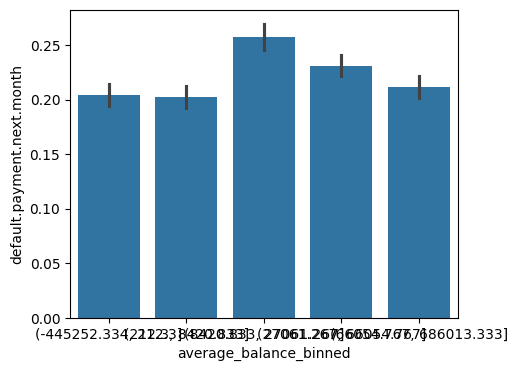

In [30]:
# Barplot of the average balance variable against the target variable with at most 5 bins, using the maximum average balance variable on the x-axis
plt.figure(figsize=(5,4))
df['average_balance_binned'] = pd.qcut(df['average_balance'], q=5)
sns.barplot(x='average_balance_binned', y=target_variable, data=df)

print("From the graph, it is now clear that the average balance variable is generally higher for those who default next month,\n"
      "that is, the default rate is higher for those with higher average balance, which makes more sense. This suggests that\n"
      "the average balance variable may be an important predictor of default next month.")

* Credit Utilization : OK

0    0.058458
1    0.016774
2    0.167843
3    0.743153
4    0.167633
Name: credit_utilization, dtype: float64


Text(0.5, 1.0, 'Credit Utilization by Default Next Month')

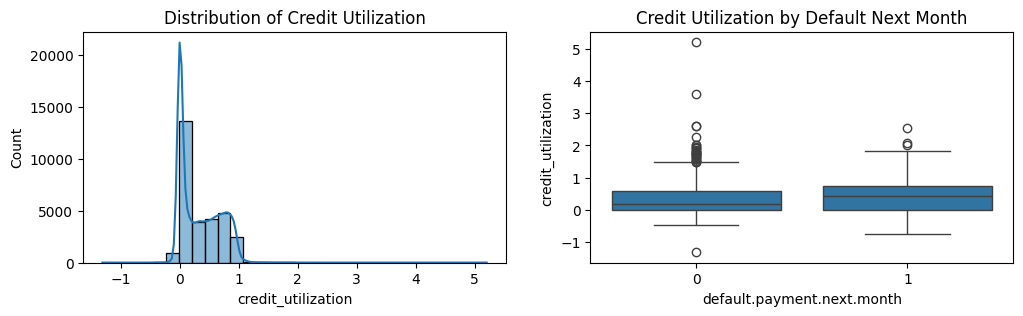

In [23]:
# Define credit utilization ratio as average balance divided by credit limit (LIMIT_BAL)
df['credit_utilization'] = (df['average_balance']) / df['LIMIT_BAL']
print(df['credit_utilization'].head())

# Plot the distribution of the credit utilization variable
plt.figure(figsize=(12,3))
plt.subplot(1, 2, 1)
sns.histplot(df['credit_utilization'], kde=True, bins=30)
plt.title('Distribution of Credit Utilization')
plt.subplot(1, 2, 2)
sns.boxplot(x=target_variable, y='credit_utilization', data=df)
plt.title('Credit Utilization by Default Next Month')

Higher credit utilization seems to be associated with higher default rates, which makes sense.


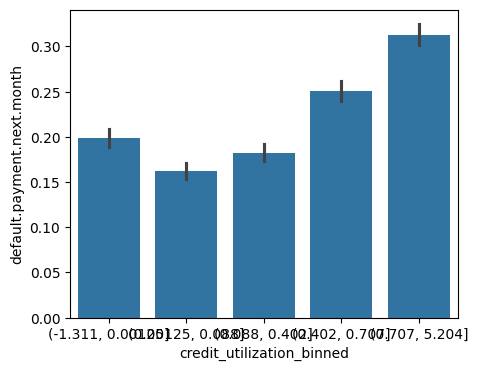

In [25]:
# Barplot of the credit utilization variable against the target variable with at most 5 bins, using the maximum credit utilization variable on the x-axis
plt.figure(figsize=(5,4))
df['credit_utilization_binned'] = pd.qcut(df['credit_utilization'], q=5)
sns.barplot(x='credit_utilization_binned', y=target_variable, data=df)

print("Higher credit utilization seems to be associated with higher default rates, which makes sense.")

* Late Payment : late_payment_PAY_1

   late_payment_PAY_1  late_payment_PAY_2  late_payment_PAY_3  \
0                   1                   1                   0   
1                   0                   1                   0   
2                   0                   0                   0   
3                   0                   0                   0   
4                   0                   0                   0   

   late_payment_PAY_4  late_payment_PAY_5  late_payment_PAY_6  
0                   0                   0                   0  
1                   0                   0                   1  
2                   0                   0                   0  
3                   0                   0                   0  
4                   0                   0                   0  
Higher late payment seems to be associated with higher default rates, which makes sense.
0    1
1    1
2    0
3    0
4    0
Name: late_payment_any, dtype: int64


<Axes: xlabel='late_payment_any', ylabel='default.payment.next.month'>

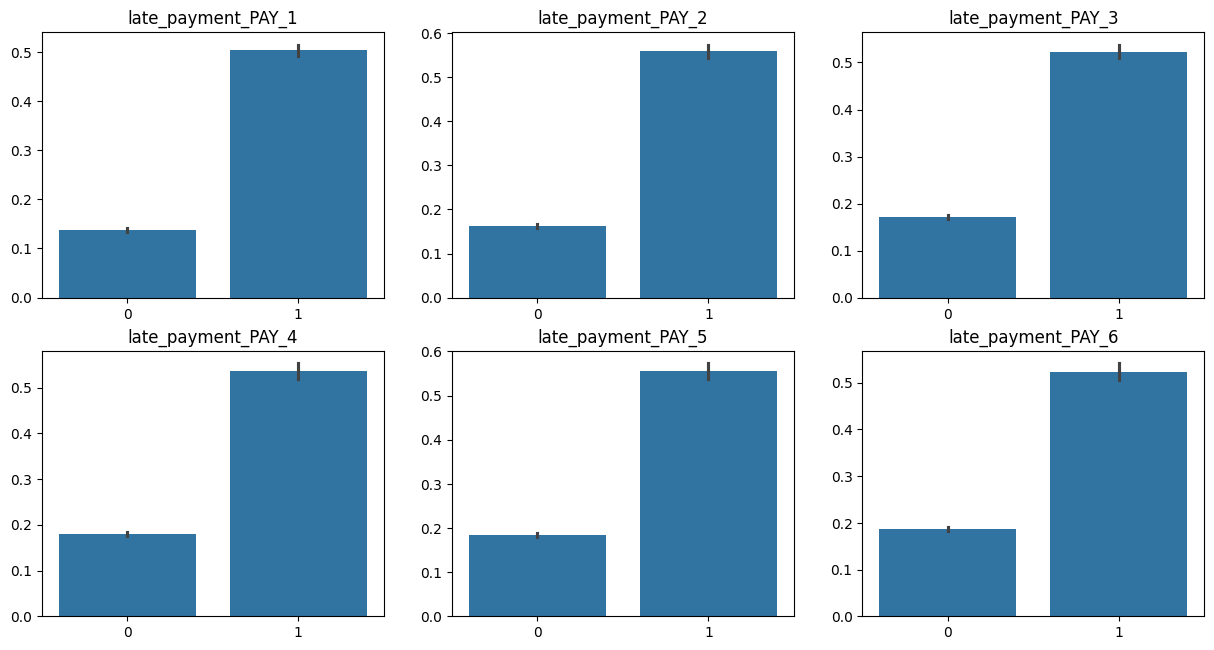

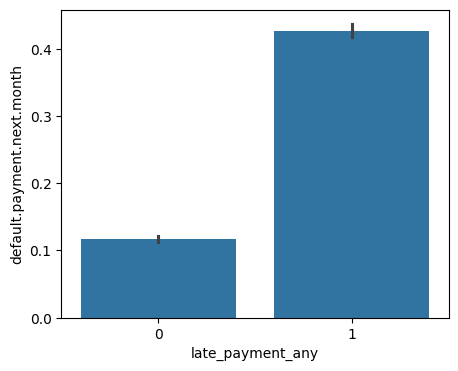

In [33]:
# Define late_payment binary variable for each month i as 1 if PAY_i > 0 and 0 otherwise
late_payment_vars = [f'PAY_{i+1}' for i in range(6)]
for var in late_payment_vars:
    df[f'late_payment_{var}'] = (df[var] > 0).astype(int)
print(df[[f'late_payment_{var}' for var in late_payment_vars]].head())

# Create barplots for each late_payment variable against the target variable with at most 5 bins, using the maximum numeric variable on the x-axis
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(late_payment_vars):
    plt.subplot(5, 3, i + 1)
    sns.barplot(x=f'late_payment_{var}', y=target_variable, data=df)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'late_payment_{var}')

print("Higher late payment seems to be associated with higher default rates, which makes sense.")

# Create another binary variable for each observation. Its value is if there was a late payment in any of the 6 months. That is, it is 1 if there was a late payment in any of the 6 months and 0 otherwise.
df['late_payment_any'] = df[[f'late_payment_{var}' for var in late_payment_vars]].max(axis=1)
print(df['late_payment_any'].head())

# Barplot of the late_payment_any variable against the target variable
plt.figure(figsize=(5,4))
sns.barplot(x='late_payment_any', y=target_variable, data=df)

# Final: Use late_payment_PAY_1. 
